In [1]:

# DAY 18 - FRAUD DETECTION USING RANDOM FOREST

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create a small fraud detection dataset

data = {
    "Transaction_Amount": [
        120, 250, 80, 5000, 150, 75, 3000, 200, 450, 7000,
        90, 180, 2500, 130, 6000
    ],

    "Transaction_Frequency": [
        2, 3, 1, 15, 2, 1, 12, 3, 4, 20,
        1, 2, 10, 2, 18
    ],

    "Account_Age_Days": [
        800, 600, 1000, 30, 700, 900, 45, 500, 400, 20,
        1200, 750, 60, 650, 25
    ],

    "International_Transaction": [
        0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
        0, 0, 1, 0, 1
    ],

    "Fraud": [
        0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
        0, 0, 1, 0, 1
    ]
}

fraud_data = pd.DataFrame(data)

print("Fraud detection dataset created successfully!")
print(fraud_data)

Fraud detection dataset created successfully!
    Transaction_Amount  Transaction_Frequency  Account_Age_Days  \
0                  120                      2               800   
1                  250                      3               600   
2                   80                      1              1000   
3                 5000                     15                30   
4                  150                      2               700   
5                   75                      1               900   
6                 3000                     12                45   
7                  200                      3               500   
8                  450                      4               400   
9                 7000                     20                20   
10                  90                      1              1200   
11                 180                      2               750   
12                2500                     10                60   
13              

In [3]:
print(fraud_data.head())

print("\nDataset shape:")
print(fraud_data.shape)

print("\nMissing values:")
print(fraud_data.isnull().sum())

print("\nFraud count:")
print(fraud_data["Fraud"].value_counts())

   Transaction_Amount  Transaction_Frequency  Account_Age_Days  \
0                 120                      2               800   
1                 250                      3               600   
2                  80                      1              1000   
3                5000                     15                30   
4                 150                      2               700   

   International_Transaction  Fraud  
0                          0      0  
1                          0      0  
2                          0      0  
3                          1      1  
4                          0      0  

Dataset shape:
(15, 5)

Missing values:
Transaction_Amount           0
Transaction_Frequency        0
Account_Age_Days             0
International_Transaction    0
Fraud                        0
dtype: int64

Fraud count:
Fraud
0    10
1     5
Name: count, dtype: int64


In [5]:
X = fraud_data[
    [
        "Transaction_Amount",
        "Transaction_Frequency",
        "Account_Age_Days",
        "International_Transaction"
    ]
]

y = fraud_data["Fraud"]

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
    Transaction_Amount  Transaction_Frequency  Account_Age_Days  \
0                  120                      2               800   
1                  250                      3               600   
2                   80                      1              1000   
3                 5000                     15                30   
4                  150                      2               700   
5                   75                      1               900   
6                 3000                     12                45   
7                  200                      3               500   
8                  450                      4               400   
9                 7000                     20                20   
10                  90                      1              1200   
11                 180                      2               750   
12                2500                     10                60   
13                 130                      2       

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (12, 4)
Testing data: (3, 4)


In [7]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=3
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [8]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)

decision_tree.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [9]:
rf_pred = random_forest.predict(X_test)
dt_pred = decision_tree.predict(X_test)

print("Random Forest Predictions:")
print(rf_pred)

print("\nDecision Tree Predictions:")
print(dt_pred)

print("\nActual Values:")
print(y_test.values)

Random Forest Predictions:
[0 1 0]

Decision Tree Predictions:
[0 1 0]

Actual Values:
[0 1 0]


In [10]:
rf_accuracy = accuracy_score(y_test, rf_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 3))
print("Decision Tree Accuracy:", round(dt_accuracy, 3))

Random Forest Accuracy: 1.0
Decision Tree Accuracy: 1.0


In [11]:
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Random Forest Confusion Matrix:
[[2 0]
 [0 1]]

Decision Tree Confusion Matrix:
[[2 0]
 [0 1]]


In [12]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred, zero_division=0))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_pred, zero_division=0))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [13]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

print(comparison)

comparison.to_csv("model_comparison.csv", index=False)
print("\nComparison saved successfully!")

           Model  Accuracy
0  Decision Tree       1.0
1  Random Forest       1.0

Comparison saved successfully!


In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

                     Feature  Importance
1      Transaction_Frequency    0.292929
0         Transaction_Amount    0.242424
2           Account_Age_Days    0.242424
3  International_Transaction    0.222222


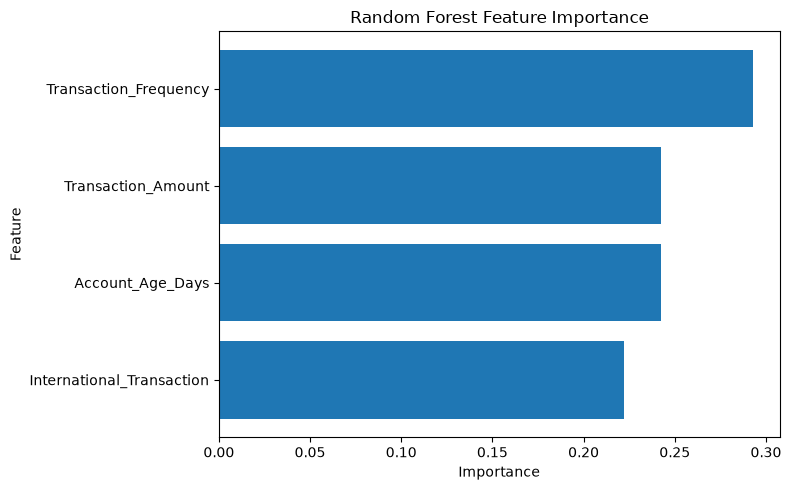

In [15]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("random_forest_feature_importance.png")
plt.show()

In [16]:
rf_train_accuracy = random_forest.score(X_train, y_train)
rf_test_accuracy = random_forest.score(X_test, y_test)

print("Training Accuracy:", round(rf_train_accuracy, 3))
print("Testing Accuracy:", round(rf_test_accuracy, 3))

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [17]:
results = X_test.copy()

results["Actual_Fraud"] = y_test.values
results["RF_Predicted"] = rf_pred
results["DT_Predicted"] = dt_pred

results.to_csv("fraud_predictions.csv", index=False)

print("Prediction results saved successfully!")
print(results)

Prediction results saved successfully!
   Transaction_Amount  Transaction_Frequency  Account_Age_Days  \
4                 150                      2               700   
9                7000                     20                20   
8                 450                      4               400   

   International_Transaction  Actual_Fraud  RF_Predicted  DT_Predicted  
4                          0             0             0             0  
9                          1             1             1             1  
8                          0             0             0             0  


In [18]:
rf_train_accuracy = random_forest.score(X_train, y_train)
rf_test_accuracy = random_forest.score(X_test, y_test)

print("Random Forest Training Accuracy:", round(rf_train_accuracy, 3))
print("Random Forest Testing Accuracy:", round(rf_test_accuracy, 3))

Random Forest Training Accuracy: 1.0
Random Forest Testing Accuracy: 1.0


In [19]:
print("Fraud Detection Challenges")

print("1. Fraud cases are usually rare and create class imbalance.")
print("2. Missing a fraudulent transaction can be costly.")
print("3. Fraud patterns can change over time.")
print("4. Models must balance fraud detection with false alarms.")
print("5. Real-world systems require large, high-quality transaction data.")

Fraud Detection Challenges
1. Fraud cases are usually rare and create class imbalance.
2. Missing a fraudulent transaction can be costly.
3. Fraud patterns can change over time.
4. Models must balance fraud detection with false alarms.
5. Real-world systems require large, high-quality transaction data.


In [20]:
print("Day 18 - Fraud Detection Using Random Forest")
print("Built Random Forest and Decision Tree models.")
print("Compared their performance.")
print("Analyzed feature importance.")
print("Checked model robustness and overfitting.")
print("Documented fraud detection challenges.")
print("Note: Dataset is synthetic and created for learning.")


Day 18 - Fraud Detection Using Random Forest
Built Random Forest and Decision Tree models.
Compared their performance.
Analyzed feature importance.
Checked model robustness and overfitting.
Documented fraud detection challenges.
Note: Dataset is synthetic and created for learning.
